In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.data_loader import load_train_data, load_stopwords
from src.eda import class_distribution, plot_class_distribution, text_length_stats

In [3]:
train_df = load_train_data("../data/raw/vsa_food_rv_train.csv")

print(train_df.head())
print(train_df.shape)
print(train_df.isnull().sum())

                                             Comment  Rating
0                                      Món ăn cực tệ     0.0
1  Mình thấy mọi người review tích cực nhưng thực...     0.0
2  Chắc với sinh viên thì ai cũng quen thuộc với ...     1.0
3  Nhiều hôm thèm lẩu riêu mà chỉ có một mình thì...     1.0
4  Không gian sạch sẽ.quán mới lên ra món hơi chậ...     1.0
(22847, 2)
Comment    4
Rating     6
dtype: int64


In [4]:
train_df = train_df.dropna(subset=["Rating"])
train_df = train_df.dropna(subset=["Comment"])
print(train_df.shape)

(22841, 2)


In [5]:
print(train_df["Rating"].value_counts())

Rating
1.0    17351
0.0     5490
Name: count, dtype: int64


In [6]:
train_df["Rating"] = train_df["Rating"].astype(int)

In [7]:
print(train_df.duplicated().sum())

9913


In [8]:
train_df = train_df.drop_duplicates()

In [9]:
train_df["length"] = train_df["Comment"].apply(lambda x: len(str(x).split()))

print(train_df["length"].describe())

count    12928.000000
mean        86.308710
std         77.958024
min          1.000000
25%         32.000000
50%         65.000000
75%        116.000000
max        907.000000
Name: length, dtype: float64


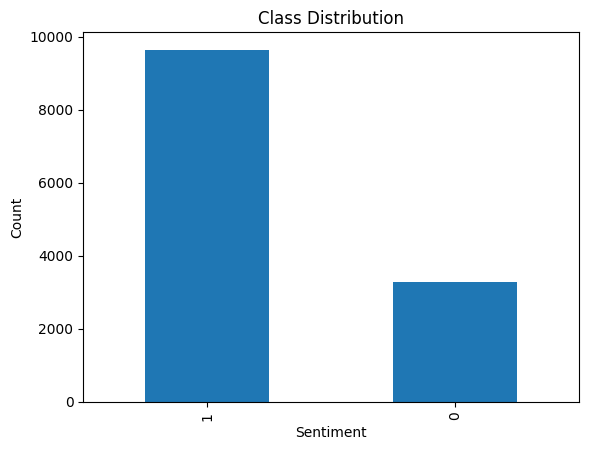

In [10]:
from src.eda import plot_class_distribution

plot_class_distribution(train_df)

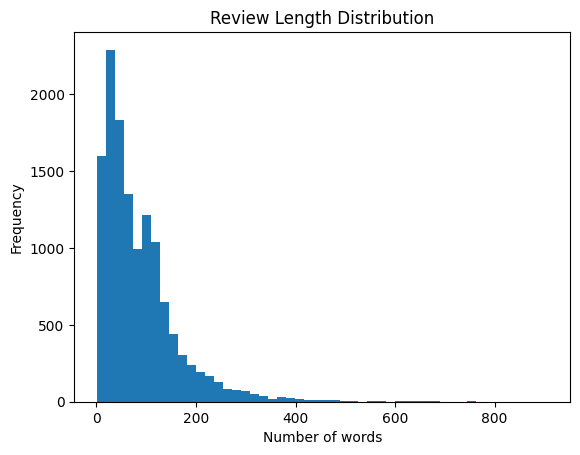

In [11]:
from src.eda import plot_text_length_histogram

plot_text_length_histogram(train_df)

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
train_temp, test_df = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df["Rating"],
    random_state=42
)

In [14]:
train_df, val_df = train_test_split(
    train_temp,
    test_size=0.111,
    stratify=train_temp["Rating"],
    random_state=42
)

In [15]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (10343, 3)
Validation: (1292, 3)
Test: (1293, 3)


In [16]:
print(train_df["Rating"].value_counts())
print(val_df["Rating"].value_counts())
print(test_df["Rating"].value_counts())

Rating
1    7710
0    2633
Name: count, dtype: int64
Rating
1    963
0    329
Name: count, dtype: int64
Rating
1    964
0    329
Name: count, dtype: int64


In [17]:
train_df.to_csv("../data/processed/train_split.csv", index=False)
val_df.to_csv("../data/processed/val_split.csv", index=False)
test_df.to_csv("../data/processed/test_split_from_train.csv", index=False)